In [45]:
import matplotlib.pyplot as plt #Using necessary library
import pandas as pd
import numpy as np
import seaborn as sns

In [46]:
from google.colab import files
uploaded = files.upload()

Saving Daily Household Transactions.csv to Daily Household Transactions (1).csv


##Exploring Data

In [47]:
#Viewing First 5 rows
df=pd.read_csv('Daily Household Transactions.csv')
df.head()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


In [48]:
df.tail()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
2456,1/1/2015,Cash,Transportation,NaN,share jeep - Place T base to top,20.0,Expense,INR
2457,1/1/2015,Cash,Transportation,NaN,share auto - Place H to Place T base,20.0,Expense,INR
2458,1/1/2015,Cash,Transportation,NaN,bus - brc to Place H,30.0,Expense,INR
2459,1/1/2015,Cash,Food,NaN,tea,10.0,Expense,INR
2460,1/1/2015,Cash,Transportation,NaN,share auto - hospital to brc station,10.0,Expense,INR


In [49]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   object 
 1   Mode            2461 non-null   object 
 2   Category        2461 non-null   object 
 3   Subcategory     1826 non-null   object 
 4   Note            1940 non-null   object 
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   object 
 7   Currency        2461 non-null   object 
dtypes: float64(1), object(7)
memory usage: 153.9+ KB


In [50]:
df.describe()

,Amount
count,2461.000000
mean,2751.145380
std,12519.615804
min,2.000000
25%,35.000000
50%,100.000000
75%,799.000000
max,250000.000000


In [51]:
df.describe(include = ["object"])

,Date,Mode,Category,Subcategory,Note,Income/Expense,Currency
count,2461,2461,2461,1826,1940,2461,2461
unique,1611,12,50,90,1057,3,1
top,1/1/2015,Saving Bank account 1,Food,Milk,milk 1lit,Expense,INR
freq,11,1223,907,162,67,2176,2461


In [52]:
df.isnull().sum()

,0
Date,0
Mode,0
Category,0
Subcategory,635
Note,521
Amount,0
Income/Expense,0
Currency,0


In [53]:
df.duplicated().sum()

9

In [54]:
df.columns

Index(['Date', 'Mode', 'Category', 'Subcategory', 'Note', 'Amount',
       'Income/Expense', 'Currency'],
      dtype='object')

In [74]:
df['Category'].unique()

array(['Transportation', 'Food', 'subscription', 'Festivals', 'Other',
       'Small Cap fund 2', 'Small cap fund 1', 'Family',
       'Equity Mutual Fund E', 'Apparel', 'Public Provident Fund',
       'Saving Bank account 1', 'Gift', 'Salary', 'Household',
       'Dividend earned on Shares', 'Interest', 'Life Insurance',
       'Beauty', 'Health', 'Money transfer', 'maid', 'Culture',
       'Tax refund', 'Tourism', 'Share Market', 'Self-development',
       'Amazon pay cashback', 'Education', 'scrap', 'Petty cash',
       'Documents', 'Gpay Reward', 'Social Life', 'Equity Mutual Fund A',
       'Maturity amount', 'Fixed Deposit', 'Equity Mutual Fund C',
       'Equity Mutual Fund F', 'Recurring Deposit',
       'Saving Bank account 2', 'Equity Mutual Fund D',
       'Equity Mutual Fund B', 'Bonus', 'Investment', 'Grooming', 'Rent',
       'Cook', 'garbage disposal', 'water (jar /tanker)'], dtype=object)

In [71]:
df["Subcategory"].unique()

array(['Train', 'snacks', 'Netflix', 'Mobile Service Provider',
       'Ganesh Pujan', 'Tata Sky', 'auto', nan, 'Grocery', 'Lunch',
       'Milk', 'Pocket money', 'Laundry', 'breakfast', 'Dinner', 'Sweets',
       'Kirana', 'Ice cream', 'curd', 'Biscuits', 'Rajgira ladu',
       'Navratri', 'train', 'Tea', 'flour mill', 'Appliances',
       'home decor', 'grooming', 'Health', 'Clothing', 'clothes', 'Home',
       'chocolate', 'Medicine', 'Eating out', 'Movie', 'vegetables',
       'fruits', 'Potato', 'Onions', 'Taxi', 'Hardware', 'Eggs', 'Bread',
       'Petrol', 'Hospital', 'Mahanagar Gas', 'Lab Tests', 'Bus',
       'Travels', 'Kitchen', 'Footwear', 'Entry Fees', 'gadgets',
       'Accessories', 'misc', 'Stationary', 'Newspaper', 'Toiletries',
       'Bike', 'beverage', 'makeup', 'Books', 'Holi', 'Courier',
       'Leisure', 'Updation', 'Amazon Prime', 'Edtech Course', 'Hotstar',
       'Diwali', 'Wifi Internet Service', 'Trip', 'Furniture', 'Water',
       'Cable TV', 'medicine', 'M

In [56]:
#Removing duplicates
df.drop_duplicates(inplace=True)

In [57]:
df

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR
...,...,...,...,...,...,...,...,...
2456,1/1/2015,Cash,Transportation,NaN,share jeep - Place T base to top,20.0,Expense,INR
2457,1/1/2015,Cash,Transportation,NaN,share auto - Place H to Place T base,20.0,Expense,INR
2458,1/1/2015,Cash,Transportation,NaN,bus - brc to Place H,30.0,Expense,INR
2459,1/1/2015,Cash,Food,NaN,tea,10.0,Expense,INR


##Now we analyze transaction data

In [58]:
# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', infer_datetime_format=True, dayfirst=True)

# Monthly Income/Expenditure
df['Month'] = df['Date'].dt.to_period('M')
monthly_income = df[df['Income/Expense'] == 'Income'].groupby('Month')['Amount'].sum()
monthly_expenditure = df[df['Income/Expense'] == 'Expense'].groupby('Month')['Amount'].sum()

<ipython-input-58-04fb0cee7b4d>:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce', infer_datetime_format=True, dayfirst=True)


In [59]:
# Spending by Category
spending_by_category = df[df['Income/Expense'] == 'Expense'].groupby('Category')['Amount'].sum()
average_spending_by_category = df[df['Income/Expense'] == 'Expense'].groupby('Category')['Amount'].mean()
top_5_categories = spending_by_category.nlargest(5)

# Transaction Type Frequency
transaction_type_frequency = df['Income/Expense'].value_counts()

In [60]:
display(monthly_income)
display(monthly_expenditure)
display(spending_by_category)
display(average_spending_by_category)
display(top_5_categories)
display(transaction_type_frequency)

,Amount
Month,
2015-02,49806.00
2015-03,70806.00
2015-04,49306.00
2015-05,47859.00
2015-06,47859.00
2015-07,47859.00
2015-08,49806.00
2015-09,49806.00
2015-10,49806.00


,Amount
Month,
2015-01,4434.00
2015-02,6710.00
2015-03,6509.80
2015-04,3791.00
2015-05,21076.00
2015-06,1198.00
2015-07,2798.00
2015-08,15507.00
2015-09,3198.00


,Amount
Category,
Apparel,25373.82
Beauty,4189.00
Cook,12443.00
Culture,4304.36
Documents,100.00
Education,537.00
Family,78582.20
Festivals,6911.00
Food,96393.10


,Amount
Category,
Apparel,539.868511
Beauty,190.409091
Cook,3110.750000
Culture,391.305455
Documents,50.000000
Education,29.833333
Family,1106.791549
Festivals,431.937500
Food,106.394150


,Amount
Category,
Money transfer,606528.90
Investment,269858.00
Transportation,169053.78
Household,161645.58
subscription,114587.91


,count
Income/Expense,
Expense,2173
Transfer-Out,154
Income,125


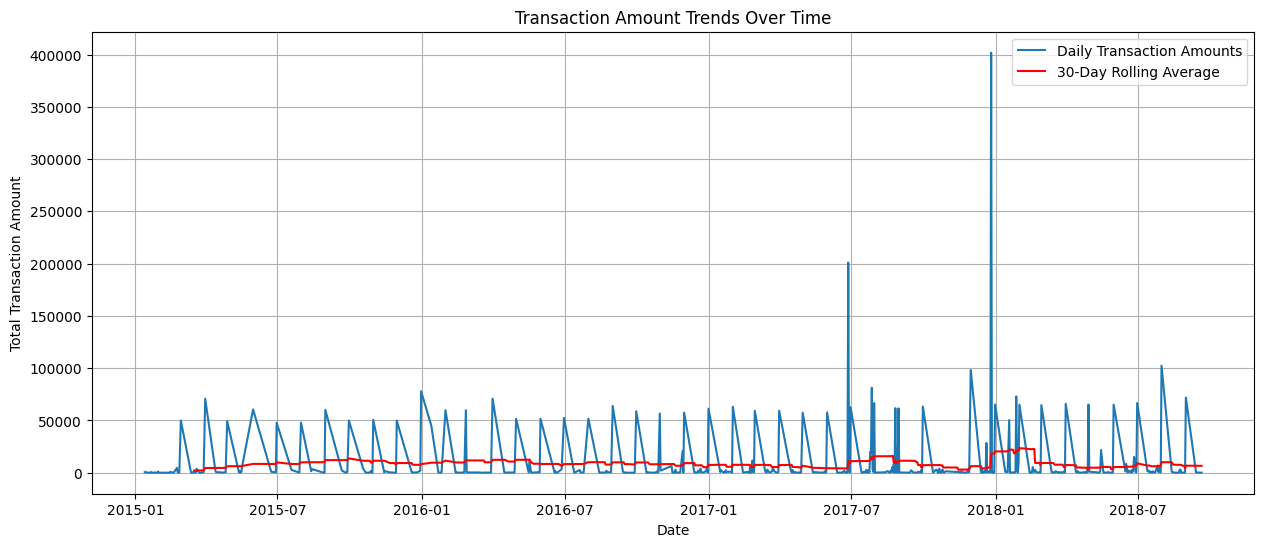

In [61]:
# Transaction Amount Trends
df['DateOnly'] = df['Date'].dt.date
daily_amounts = df.groupby('DateOnly')['Amount'].sum()
rolling_avg = daily_amounts.rolling(window=30).mean()

plt.figure(figsize=(15, 6))
plt.plot(daily_amounts.index, daily_amounts.values, label='Daily Transaction Amounts')
plt.plot(rolling_avg.index, rolling_avg.values, label='30-Day Rolling Average', color='red')
plt.xlabel('Date')
plt.ylabel('Total Transaction Amount')
plt.title('Transaction Amount Trends Over Time')
plt.legend()
plt.grid(True)
plt.show()

## Now we use Data visualization for better insights

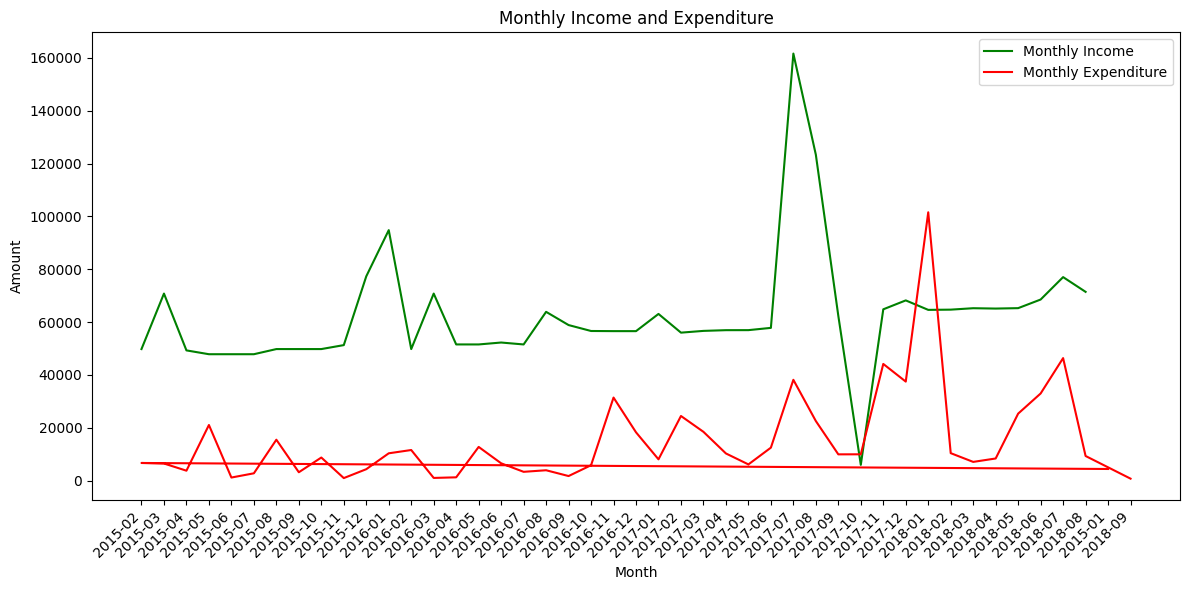

In [62]:
plt.figure(figsize=(12, 6))

# Time series plot of monthly income and expenditure
plt.plot(monthly_income.index.astype(str), monthly_income.values, label='Monthly Income', color='green')
plt.plot(monthly_expenditure.index.astype(str), monthly_expenditure.values, label='Monthly Expenditure', color='red')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.title('Monthly Income and Expenditure')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

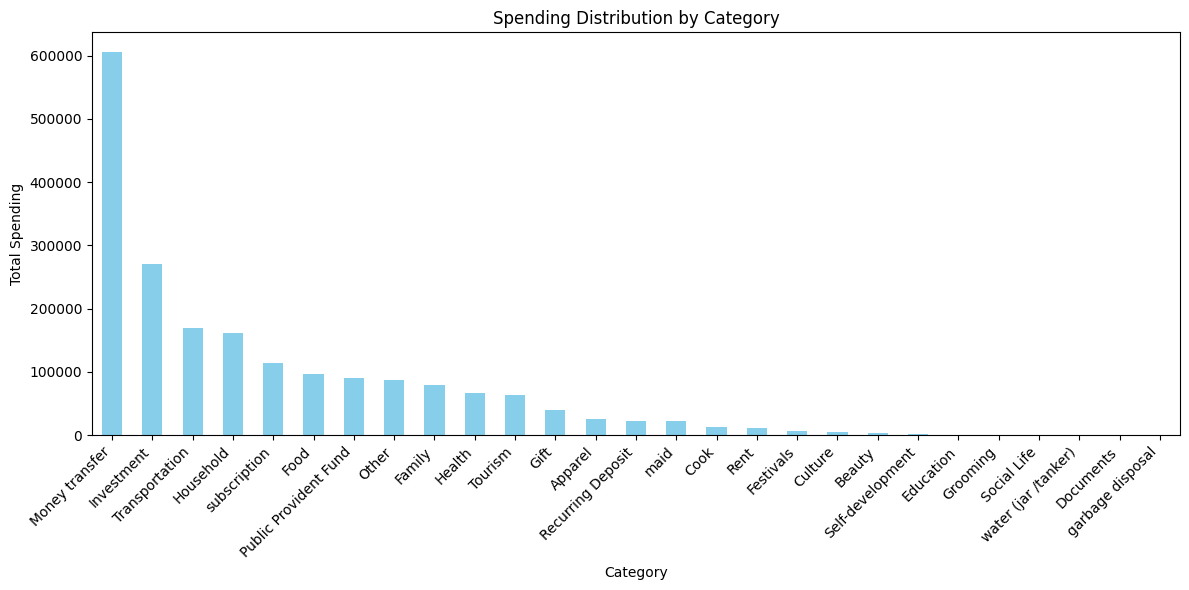

In [63]:
# Bar chart of spending by category
plt.figure(figsize=(12, 6))
spending_by_category.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.xlabel('Category')
plt.ylabel('Total Spending')
plt.title('Spending Distribution by Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

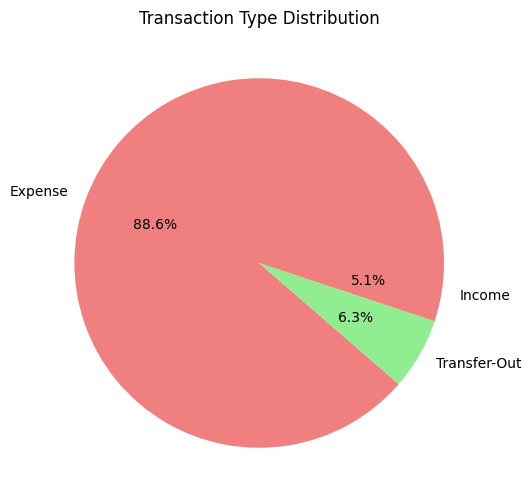

In [64]:
# Pie chart of transaction types
plt.figure(figsize=(6, 6))
transaction_type_frequency.plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
plt.title('Transaction Type Distribution')
plt.ylabel('')
plt.show()


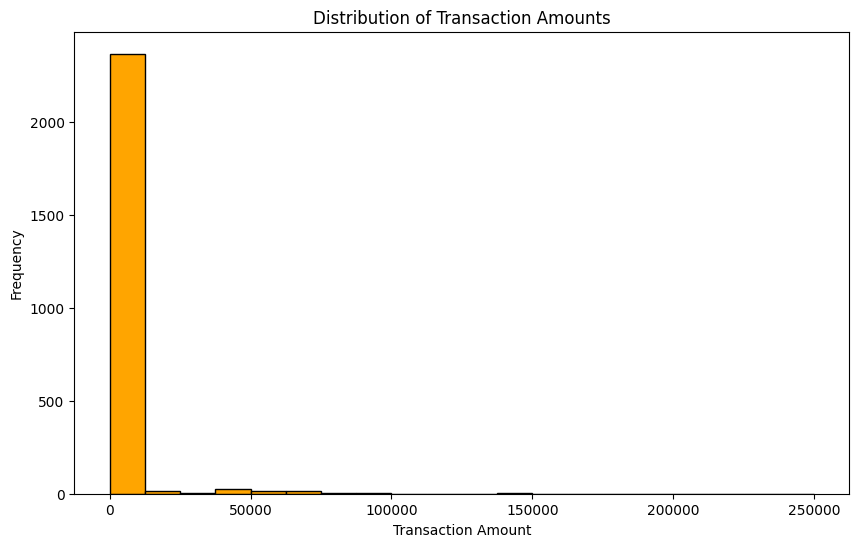

In [65]:
# Histogram of transaction amounts
plt.figure(figsize=(10, 6))
plt.hist(df['Amount'], bins=20, color='orange', edgecolor='black')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Transaction Amounts')
plt.show()

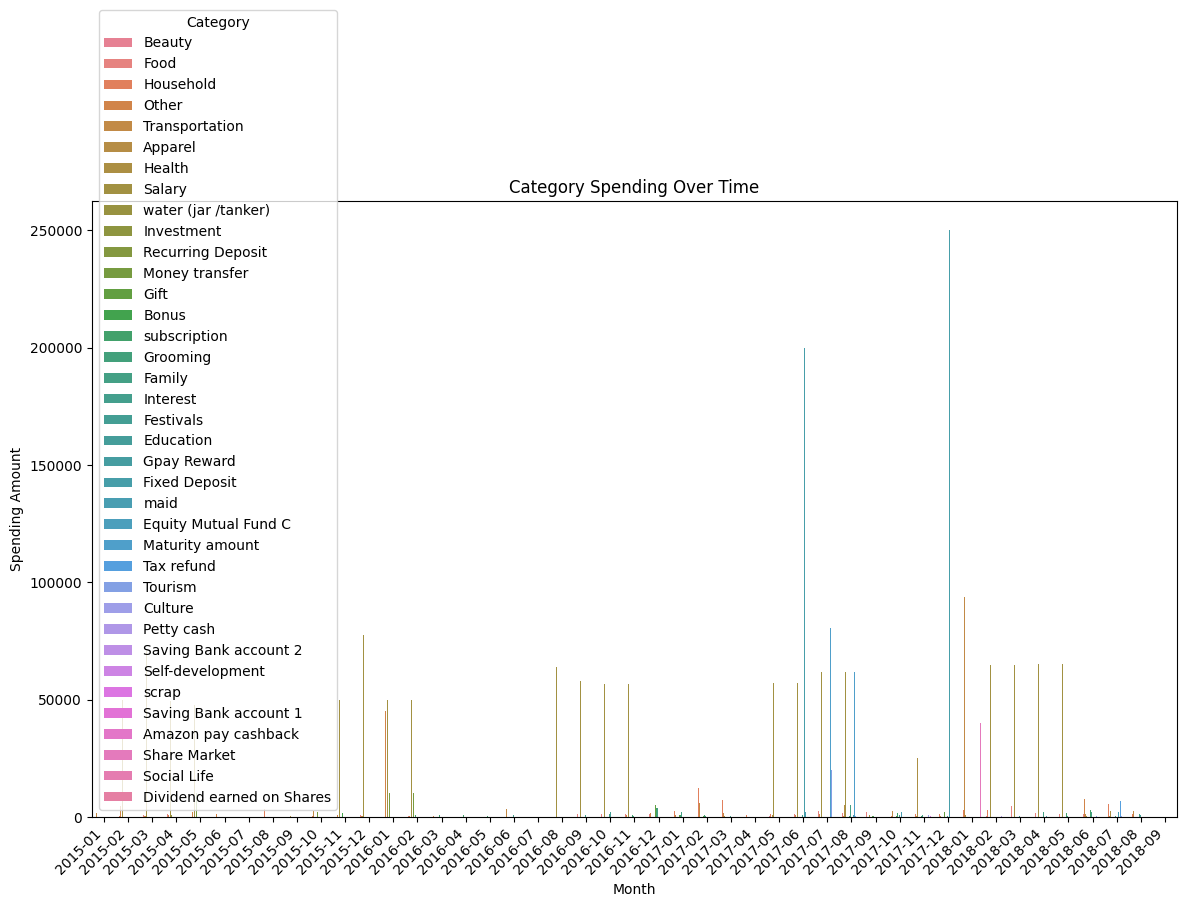

In [66]:
# Category Spending Over Time
category_spending_over_time = df.groupby(
    [df['Date'].dt.to_period('M'), 'Category'])['Amount'].sum().reset_index()
category_spending_over_time['Date'] = category_spending_over_time['Date'].astype(str)

plt.figure(figsize=(14, 8))
sns.barplot(data=category_spending_over_time,x='Date', y='Amount', hue='Category')
plt.title('Category Spending Over Time')
plt.xlabel('Month')
plt.ylabel('Spending Amount')
plt.xticks(rotation=45, ha='right')
plt.show()

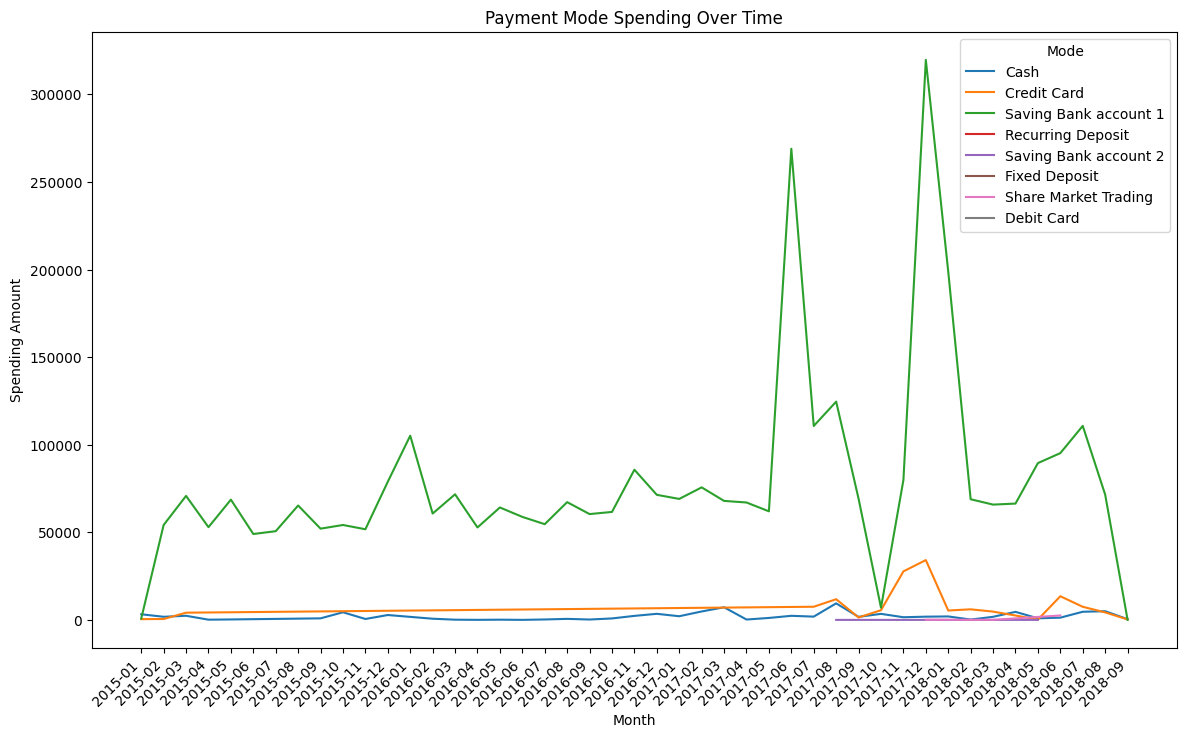

In [67]:
# Payment Mode Preference Over Time
payment_mode_over_time = df.groupby(
    [df['Date'].dt.to_period('M'), 'Mode'])['Amount'].sum().reset_index()
payment_mode_over_time['Date'] = payment_mode_over_time['Date'].astype(str)

plt.figure(figsize=(14, 8))
sns.lineplot(data=payment_mode_over_time, x='Date', y='Amount', hue='Mode')
plt.title('Payment Mode Spending Over Time')
plt.xlabel('Month')
plt.ylabel('Spending Amount')
plt.xticks(rotation=45, ha='right')
plt.show()

In [68]:
# Simple Anomaly Detection using Z-score
df['Amount_zscore'] = np.abs((df['Amount'] - df['Amount'].mean()) / df['Amount'].std())
anomaly_threshold = 3
anomalies = df[df['Amount_zscore'] > anomaly_threshold]
print("Potential Anomalies:")
print(anomalies)


Potential Anomalies:
                    Date                   Mode Category Subcategory  \
33   2018-08-31 09:27:28  Saving Bank account 1   Salary         NaN   
105  2018-07-31 09:05:17  Saving Bank account 1   Salary         NaN   
195  2018-06-30 08:44:48  Saving Bank account 1   Salary         NaN   
250  2018-05-31 08:47:33  Saving Bank account 1   Salary         NaN   
323  2018-04-29 09:36:56  Saving Bank account 1   Salary         NaN   
...                  ...                    ...      ...         ...   
2187 2015-06-30 09:53:35  Saving Bank account 1   Salary         NaN   
2200 2015-05-31 12:02:40  Saving Bank account 1   Salary         NaN   
2232 2015-04-28 15:44:31  Saving Bank account 1   Salary         NaN   
2256 2015-03-31 13:00:05  Saving Bank account 1   Salary         NaN   
2317 2015-02-28 17:30:58  Saving Bank account 1   Salary         NaN   

                 Note   Amount Income/Expense Currency    Month    DateOnly  \
33    From workplace   70255.0     

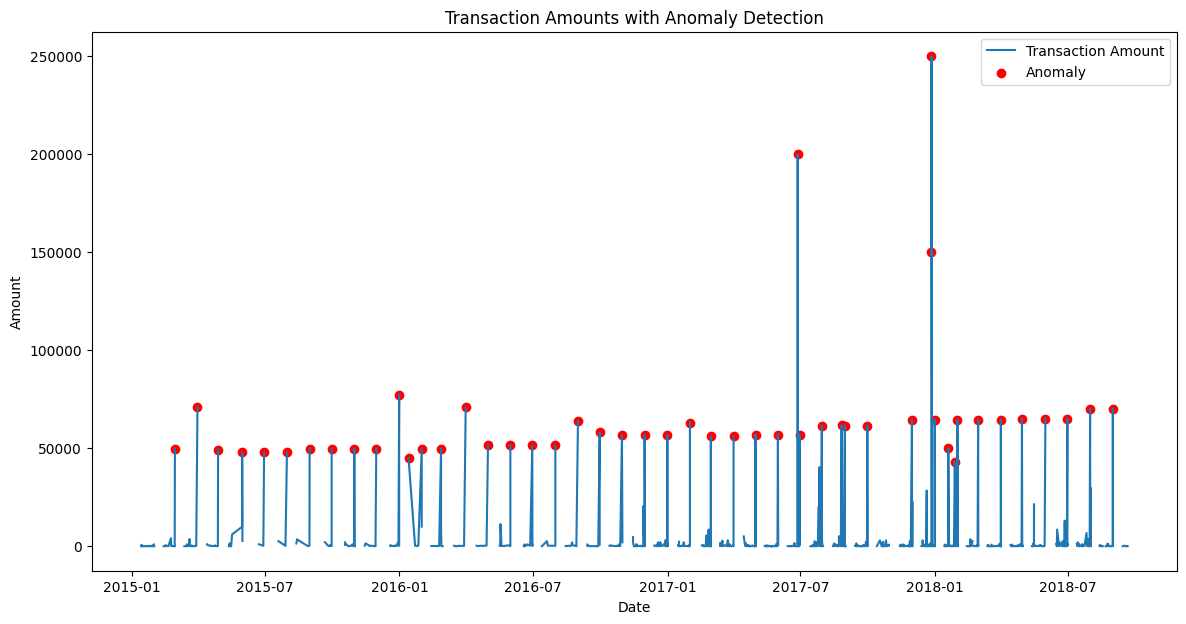

In [69]:
# Visualize anomalies
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Amount'], label='Transaction Amount')
plt.scatter(anomalies['Date'], anomalies['Amount'], color='red', label='Anomaly')
plt.title('Transaction Amounts with Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.legend()
plt.show()

##Insights from the Analysis:

#The analysis of daily household transactions provides several valuable insights into financial habits and spending patterns

Income vs. Expenses:

Monthly income and expenditure trends fluctuate, helping identify high-spending periods.
A pie chart shows the proportion of income vs. expense, giving a clear financial picture.

Spending Patterns & Categories:

Major expense categories are visualized using bar charts, identifying top spending areas.
Spending distribution is analyzed using histograms, showing variations in transaction amounts.

Payment Behavior Analysis:

Preferred payment modes (cash, credit, Bank, etc.) are tracked over time.
Trends in different spending categories reveal where most money is spent.

Anomaly Detection & Trend Identification:

Z-score analysis helps detect unusual financial transactions, indicating potential anomalies.
Rolling averages highlight spending trends and predict future financial behavior.

This analysis helps in better financial management, allowing users to track their spending habits, control expenses, and detect anomalies for improved budgeting and financial planning.